<a href='https://www.darshan.ac.in/'> <img src='https://www.darshan.ac.in/Content/media/DU_Logo.svg' width="250" height="300"/></a>
<pre>
<center><b><h1>Machine Learning - 2301CS621</b></center>

<center><b><h1>Lab - 13 </b></center>
<pre>    

## Step 1: Import Necessary Libraries
complete the import statements below.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.datasets import load_iris

## Step 2: Load the Dataset
Load the dataset (e.g., Iris dataset) or use your own.

In [3]:
data = load_iris()
X=data.data
y=data.target

## Step 3: Preprocess the Data (Standardization)
Standardize the dataset before applying PCA or LDA.

In [4]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [5]:
X_scaled

array([[-9.00681170e-01,  1.01900435e+00, -1.34022653e+00,
        -1.31544430e+00],
       [-1.14301691e+00, -1.31979479e-01, -1.34022653e+00,
        -1.31544430e+00],
       [-1.38535265e+00,  3.28414053e-01, -1.39706395e+00,
        -1.31544430e+00],
       [-1.50652052e+00,  9.82172869e-02, -1.28338910e+00,
        -1.31544430e+00],
       [-1.02184904e+00,  1.24920112e+00, -1.34022653e+00,
        -1.31544430e+00],
       [-5.37177559e-01,  1.93979142e+00, -1.16971425e+00,
        -1.05217993e+00],
       [-1.50652052e+00,  7.88807586e-01, -1.34022653e+00,
        -1.18381211e+00],
       [-1.02184904e+00,  7.88807586e-01, -1.28338910e+00,
        -1.31544430e+00],
       [-1.74885626e+00, -3.62176246e-01, -1.34022653e+00,
        -1.31544430e+00],
       [-1.14301691e+00,  9.82172869e-02, -1.28338910e+00,
        -1.44707648e+00],
       [-5.37177559e-01,  1.47939788e+00, -1.28338910e+00,
        -1.31544430e+00],
       [-1.26418478e+00,  7.88807586e-01, -1.22655167e+00,
      

## Step 4: Apply PCA
Perform PCA and extract the principal components.

In [6]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

In [7]:
X_pca

array([[-2.26470281,  0.4800266 ],
       [-2.08096115, -0.67413356],
       [-2.36422905, -0.34190802],
       [-2.29938422, -0.59739451],
       [-2.38984217,  0.64683538],
       [-2.07563095,  1.48917752],
       [-2.44402884,  0.0476442 ],
       [-2.23284716,  0.22314807],
       [-2.33464048, -1.11532768],
       [-2.18432817, -0.46901356],
       [-2.1663101 ,  1.04369065],
       [-2.32613087,  0.13307834],
       [-2.2184509 , -0.72867617],
       [-2.6331007 , -0.96150673],
       [-2.1987406 ,  1.86005711],
       [-2.26221453,  2.68628449],
       [-2.2075877 ,  1.48360936],
       [-2.19034951,  0.48883832],
       [-1.898572  ,  1.40501879],
       [-2.34336905,  1.12784938],
       [-1.914323  ,  0.40885571],
       [-2.20701284,  0.92412143],
       [-2.7743447 ,  0.45834367],
       [-1.81866953,  0.08555853],
       [-2.22716331,  0.13725446],
       [-1.95184633, -0.62561859],
       [-2.05115137,  0.24216355],
       [-2.16857717,  0.52714953],
       [-2.13956345,

## Step 5: Visualization
Visualize PCA results using scatter plots.

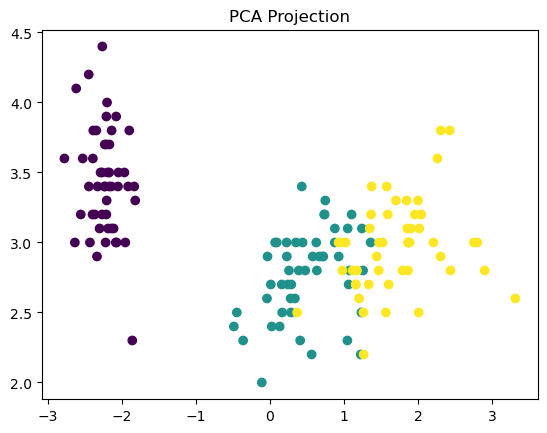

In [8]:
plt.scatter(X_pca[:,0], x[:,1],c=y, cmap='viridis')
plt.title('PCA Projection')
plt.show()

## Train the model using above data 

C:\Users\ASUS\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


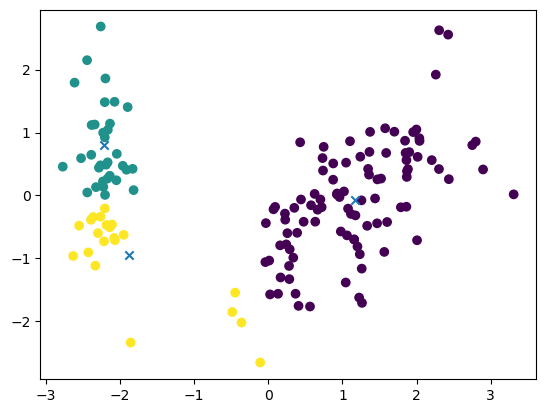

In [13]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=3, random_state=42)
kmeans_labels = kmeans.fit_predict(X_pca)
centerdata = kmeans.cluster_centers_

plt.scatter(X_pca[:,0],X_pca[:,1],c=kmeans_labels)
plt.scatter(centerdata[:,0], centerdata[:,1],marker="x")
plt.show()



## Step 6: Feature Selection using Filter Methods
In this section, you will apply different filter methods such as:
- **Pearson Correlation Coefficient**
- **Chi-Square Test**
- **Variance Thresholding**

### 8.1 Pearson Correlation Coefficient
Calculate the correlation between features and the target variable.

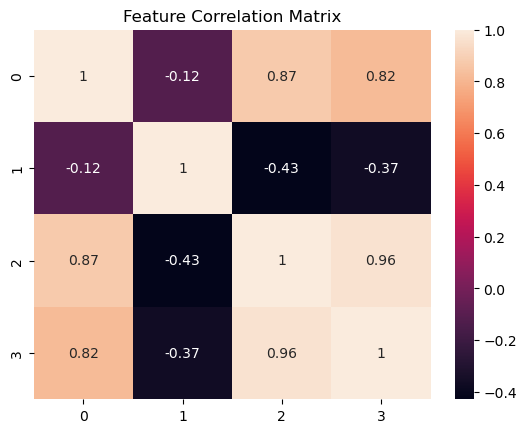

In [14]:
import seaborn as sns

correlation_matrix = np.corrcoef(X_scaled.T)
sns.heatmap(correlation_matrix, annot=True)
plt.title('Feature Correlation Matrix')
plt.show()

### 8.2 Chi-Square Test
Use the Chi-Square test to determine the relationship between features and the target variable.

In [16]:
from sklearn.feature_selection import chi2

In [17]:
chi2(X,y)

(array([ 10.81782088,   3.7107283 , 116.31261309,  67.0483602 ]),
 array([4.47651499e-03, 1.56395980e-01, 5.53397228e-26, 2.75824965e-15]))

### 8.3 Variance Thresholding
Remove features with low variance as they may not be useful for predictions.

## Step 9: Feature Selection using Wrapper Methods
Wrapper methods evaluate feature subsets based on model performance.
In this section, we will use:
- **Recursive Feature Elimination (RFE)**
- **Sequential Feature Selection (SFS)**

### 9.1 Recursive Feature Elimination (RFE)
RFE removes the least important features iteratively until the optimal subset is reached.

### 9.2 Sequential Feature Selection (SFS)
SFS iteratively selects the best-performing features by adding or removing them.

## Step 10: Applying PCA on Digits Dataset
In this section, we will apply PCA on the `load_digits` dataset, which consists of handwritten digit images, and visualize its effect.

### 10.1 Load and Visualize the Digits Dataset
We will load the dataset and visualize some sample images.

In [18]:
from sklearn.datasets import load_digits

digits = load_digits()
X_digits = digits.data
y_digits = digits.target

In [20]:
digits.images[0]

array([[ 0.,  0.,  5., 13.,  9.,  1.,  0.,  0.],
       [ 0.,  0., 13., 15., 10., 15.,  5.,  0.],
       [ 0.,  3., 15.,  2.,  0., 11.,  8.,  0.],
       [ 0.,  4., 12.,  0.,  0.,  8.,  8.,  0.],
       [ 0.,  5.,  8.,  0.,  0.,  9.,  8.,  0.],
       [ 0.,  4., 11.,  0.,  1., 12.,  7.,  0.],
       [ 0.,  2., 14.,  5., 10., 12.,  0.,  0.],
       [ 0.,  0.,  6., 13., 10.,  0.,  0.,  0.]])

### 10.2 Apply PCA and Reduce Dimensions
We will reduce the dataset to 2 principal components and visualize the transformed data.

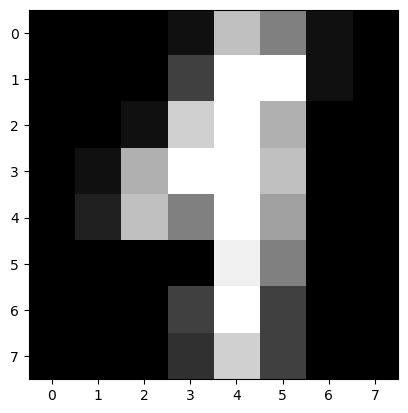

In [23]:
plt.imshow(digits.images[90],cmap='gray')

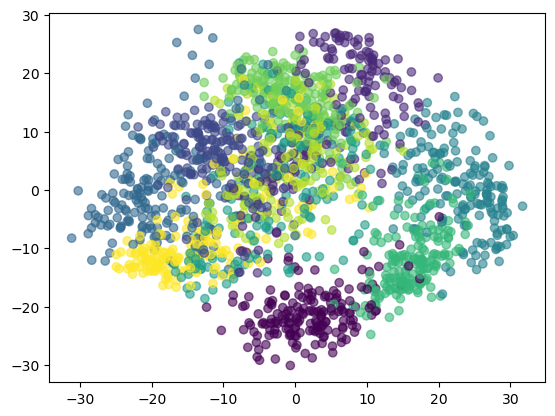

In [24]:
from sklearn.decomposition import PCA
import numpy as np

pca_digits = PCA(n_components=2)
X_pca_digits = pca_digits.fit_transform(X_digits, y_digits)

plt.scatter(X_pca_digits[:,0],X_pca_digits[:, 1], c=y_digits,cmap='viridis',alpha=0.6)
plt.show()